# CLIP Event Classifier — Fine-tuning для Волонтёр+

Бинарный классификатор: **«фото с мероприятия»** vs **«не мероприятие»**.
Используется как Блок 4 в пайплайне верификации (`bot/utils/ai_moderation.py`).

## Архитектура
```
openai/clip-vit-base-patch16  (visual encoder, ЗАМОРОЖЕН)
  └── image_features: [B, 512]
        └── CLIPEventClassifier.head:
              LayerNorm(512) → Dropout(0.2) → Linear(512→128)
              → GELU → Dropout(0.1) → Linear(128→2)
```

## Датасеты
| Источник | Класс | ~Размер | Вес в sampler |
|----------|-------|---------|---------------|
| WIDER FACE (лекции, митинги, церемонии) | `event=1` | ~5 000 | 1× base |
| WIDER FACE (спорт) | `event=0` | ~8 000 | 1× base |
| Places365 mini на HF + опц. streaming (`dpdl-benchmark/places365-mini-*`) | `event=0` | до ~7 500 | 1× base |
| MIT Indoor (пустые аудитории) | `event=0` (hard negative) | ~700 | **2×** base |

## Запуск
Kaggle → Settings → Accelerator → **GPU T4 x2** (или P100)

После обучения скачать `clip_event_classifier.pt` → положить в `bot/models/`.

## 1. Зависимости

In [1]:
# Kaggle обычно имеет transformers и torch, но albumentations нужно поставить
!pip install -q albumentations transformers datasets torch torchvision scikit-learn tqdm

## 2. Импорты и конфигурация

In [2]:
import json
import os
import random
import warnings
from collections import Counter
from pathlib import Path

import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
from datasets import load_dataset, DownloadConfig, Dataset as HFDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, roc_auc_score,
)
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Воспроизводимость ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# ── Конфигурация ───────────────────────────────────────────────────────────
CLIP_MODEL_ID  = 'openai/clip-vit-base-patch16'
CLIP_IMAGE_SIZE = 224
# Нормализация из оригинального CLIP (openai/clip)
CLIP_MEAN = (0.48145466, 0.4578275,  0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)

BATCH_SIZE    = 128       # уменьши до 16 если OOM на T4
EPOCHS        = 6
LR            = 1e-4
WEIGHT_DECAY  = 1e-2
VAL_SPLIT     = 0.15

# Hard negative множитель (MIT Indoor пустые аудитории)
HARD_NEG_MULTIPLIER = 2.0

# Лимиты на источники
MAX_WIDER_POSITIVE = 5_000
MAX_WIDER_NEGATIVE = 8_000
MAX_PLACES365_PER_CAT = 500    # на категорию (если есть разметка по классам)
MAX_PLACES365_TOTAL = 7_500    # верхняя граница негативов со сцен
MAX_MIT_INDOOR = 800

# Таймаут Hugging Face (полный Places365 ~2.2 GB часто падает по timeout)
os.environ.setdefault('HF_HUB_DOWNLOAD_TIMEOUT', '600')

MODEL_OUT = 'clip_event_classifier.pt'

# ── Классы WIDER FACE ──────────────────────────────────────────────────────
# Сцены с толпой/мероприятием (WIDER FACE: папки NN--Category)
EVENT_CLASSES = {
    'Lecture', 'Meeting', 'Press_conference',
    'Ceremony', 'Commencement', 'Pageant', 'Festival',
    'Parade', 'Demonstration', 'People_Marching', 'Cheering',
}
SPORT_CLASSES = {
    'Basketball', 'Swimming', 'Tennis', 'Running',
    'Soccer', 'Volleyball', 'Aerobics', 'Baseball',
    'Gymnastic', 'Ski', 'Jockey',
}
PLACES365_CATEGORIES = [
    'bedroom', 'bathroom', 'kitchen', 'living_room',
    'corridor', 'forest', 'beach', 'mountain',
    'field', 'street', 'parking_lot', 'restaurant',
    'bar', 'market', 'closet',
]
# Имена классов MIT Indoor (parquet): classroom, auditorium, meeting_room, …
MIT_TARGET_CATS = {
    'classroom', 'lecture_theatre', 'auditorium', 'conference_room',
    'meeting_room', 'concert_hall',
}

print('Config OK')

Config OK


## 3. Аугментации и нормализация

In [4]:
# Для train: геометрические + цветовые аугментации + CLIP нормализация
# Для val: только resize + нормализация (без случайности)
# ToTensorV2: numpy HWC uint8 → torch CHW float32 (без масштабирования!)
# Поэтому Normalize идёт ДО ToTensorV2 и работает с float32 от 0..1,
# но albumentations Normalize по умолчанию делит на max_pixel_value=255 внутри.

train_transforms = A.Compose([
    # Resize чуть больше размера кропа — оставляем запас для RandomCrop
    A.SmallestMaxSize(max_size=256),
    A.RandomCrop(height=CLIP_IMAGE_SIZE, width=CLIP_IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.1, p=0.7,
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.Rotate(limit=10, p=0.3),
    # Нормализация со статистиками CLIP
    A.Normalize(mean=CLIP_MEAN, std=CLIP_STD, max_pixel_value=255.0),
    ToTensorV2(),   # HWC → CHW, dtype=float32
])

val_transforms = A.Compose([
    A.Resize(CLIP_IMAGE_SIZE, CLIP_IMAGE_SIZE),
    A.Normalize(mean=CLIP_MEAN, std=CLIP_STD, max_pixel_value=255.0),
    ToTensorV2(),
])

print('Transforms OK')
print('Train pipeline:', [t.__class__.__name__ for t in train_transforms.transforms])

Transforms OK
Train pipeline: ['SmallestMaxSize', 'RandomCrop', 'HorizontalFlip', 'ColorJitter', 'GaussianBlur', 'GaussNoise', 'Rotate', 'Normalize', 'ToTensorV2']


## 4. Модель: CLIPEventClassifier

In [5]:
class CLIPEventClassifier(nn.Module):
    """CLIP visual encoder (frozen) + trainable classification head.

    Входной тензор pixel_values: [B, 3, 224, 224] нормализованный по CLIP статистике.
    Выход logits: [B, 2]  (0=not_event, 1=event)
    """

    def __init__(self, model_id: str = 'openai/clip-vit-base-patch16'):
        super().__init__()

        # ── Visual encoder ────────────────────────────────────────────────
        self.clip = CLIPModel.from_pretrained(model_id)
        # Замораживаем все параметры CLIP — обучаем только head
        for param in self.clip.parameters():
            param.requires_grad = False

        embed_dim = self.clip.config.projection_dim  # 512 для vit-base

        # ── Classification head ───────────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(p=0.2),
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 2),
        )

        self.embed_dim = embed_dim

    def extract_features(self, pixel_values: torch.Tensor) -> torch.Tensor:
        """Извлекает image embeddings через замороженный CLIP encoder.

        Явно вызываем vision_model + visual_projection вместо get_image_features(),
        чтобы гарантированно получить torch.Tensor независимо от версии transformers
        (в некоторых версиях get_image_features возвращает BaseModelOutputWithPooling).
        """
        with torch.no_grad():
            vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
            return self.clip.visual_projection(vision_outputs.pooler_output)

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        features = self.extract_features(pixel_values)  # [B, 512]
        return self.head(features)                       # [B, 2]

    def trainable_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def frozen_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if not p.requires_grad)


# Быстрая проверка без GPU
print(f'Загружаем {CLIP_MODEL_ID}...')
model = CLIPEventClassifier(CLIP_MODEL_ID).to(DEVICE)
print(f'embed_dim:       {model.embed_dim}')
print(f'Заморожено:     {model.frozen_params():,} параметров')
print(f'Обучается:      {model.trainable_params():,} параметров')

# Smoke test
dummy = torch.zeros(2, 3, CLIP_IMAGE_SIZE, CLIP_IMAGE_SIZE).to(DEVICE)
out = model(dummy)
print(f'Output shape:   {out.shape}  (ожидается [2, 2])')
assert out.shape == (2, 2), 'Ошибка: неправильная форма выхода'


Загружаем openai/clip-vit-base-patch16...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embed_dim:       512
Заморожено:     149,620,737 параметров
Обучается:      66,946 параметров
Output shape:   torch.Size([2, 2])  (ожидается [2, 2])


## 5. Dataset класс

In [6]:
class EventPhotoDataset(Dataset):
    """Ленивая загрузка изображений по записям (records).

    Каждая запись: (loader, label: int, source: str)
    loader — одно из двух:
      • Path  → PIL.Image.open(loader)          — для WIDER FACE с диска
      • (HFDataset, int) → hf_ds[idx]['image']  — для Places365 / MIT Indoor

    PIL-декодирование происходит только в __getitem__, не при создании датасета.
    """

    def __init__(self, records: list, transforms: A.Compose):
        self.records = records
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int):
        loader, label, _ = self.records[idx]

        if isinstance(loader, Path):
            img = Image.open(loader).convert('RGB')
        else:
            hf_ds, hf_idx = loader
            raw = hf_ds[hf_idx]['image']
            img = raw if isinstance(raw, Image.Image) else Image.fromarray(np.array(raw))
            img = img.convert('RGB')

        img_np = np.array(img, dtype=np.uint8)
        augmented = self.transforms(image=img_np)
        return augmented['image'], torch.tensor(label, dtype=torch.long)


## 6. Загрузка датасетов

In [7]:
# ── Источник 1: WIDER FACE — из Kaggle Dataset (локальные файлы) ──────────
# Добавить датасет: + Add Data → "wider-face-a-face-detection-dataset"
# Важно: раньше бралась только ПЕРВАЯ найденная папка images (часто только WIDER_test)
# → мало классов «event». Собираем ВСЕ корни .../images, где есть NN--Category.

WIDER_BASE_CANDIDATES = [
    Path('/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset'),
]

WIDER_BASE = next((p for p in WIDER_BASE_CANDIDATES if p.exists()), WIDER_BASE_CANDIDATES[0])


def _find_all_wider_image_roots(base: Path) -> list[Path]:
    """Все каталоги images, содержащие подпапки вида 12--Category."""
    roots: set[Path] = set()
    if not base.exists():
        return []
    for candidate in base.rglob('*'):
        if not candidate.is_dir() or '--' not in candidate.name:
            continue
        prefix = candidate.name.split('--', 1)[0]
        if prefix.isdigit():
            roots.add(candidate.parent)
    return sorted(roots)


print('Сканируем WIDER FACE (все splits: train + test, только пути)...')
wider_records = []

roots = _find_all_wider_image_roots(WIDER_BASE)
if not roots:
    print(f'WIDER FACE не найден в {WIDER_BASE}')
    print('→ Добавьте iamprateek/wider-face-a-face-detection-dataset или укажите путь в WIDER_BASE_CANDIDATES')
else:
    print(f'Найдено корней images: {len(roots)}')
    for r in roots:
        print(f'  • {r}')

    event_paths: list[Path] = []
    sport_paths: list[Path] = []

    for images_root in roots:
        for cat_dir in sorted(images_root.iterdir()):
            if not cat_dir.is_dir():
                continue
            stripped = cat_dir.name.split('--', 1)[-1] if '--' in cat_dir.name else cat_dir.name
            if stripped in EVENT_CLASSES:
                event_paths.extend(cat_dir.glob('*.jpg'))
            elif stripped in SPORT_CLASSES:
                sport_paths.extend(cat_dir.glob('*.jpg'))

    # Дедуп по реальному пути (на случай дублей)
    def _dedupe(paths: list[Path]) -> list[Path]:
        seen: set[Path] = set()
        out: list[Path] = []
        for p in paths:
            try:
                k = p.resolve()
            except OSError:
                k = p
            if k not in seen:
                seen.add(k)
                out.append(p)
        return out

    event_paths = _dedupe(event_paths)
    sport_paths = _dedupe(sport_paths)
    random.shuffle(event_paths)
    random.shuffle(sport_paths)
    event_paths = event_paths[:MAX_WIDER_POSITIVE]
    sport_paths = sport_paths[:MAX_WIDER_NEGATIVE]

    wider_records = (
        [(p, 1, 'wider_event') for p in event_paths]
        + [(p, 0, 'wider_sport') for p in sport_paths]
    )
    print(
        f'WIDER FACE: {len(wider_records)} записей '
        f'(event={len(event_paths)}, sport={len(sport_paths)})'
    )


Сканируем WIDER FACE (все splits: train + test, только пути)...
Найдено корней images: 3
  • /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_test/WIDER_test/images
  • /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images
  • /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images
WIDER FACE: 9373 записей (event=5000, sport=4373)


In [8]:
# Подтверждение — wider_records уже готов выше
print(f'wider_records: {len(wider_records)} записей')
print(f'  event=1: {sum(1 for r in wider_records if r[1] == 1)}')
print(f'  event=0: {sum(1 for r in wider_records if r[1] == 0)}')


wider_records: 9373 записей
  event=1: 5000
  event=0: 4373


In [9]:
# Ячейка-заглушка (логика перенесена в load-wider)
print('WIDER FACE готов.')


WIDER FACE готов.


In [10]:
# ── Источник 2: Places365 — негативный класс (сцены без «ивента») ───────────
# Полный Places365-Validation (~2.2 GB parquet) часто даёт timeout на Kaggle/HF.
# Сначала пробуем лёгкий сабсет (~459 MB), затем streaming с полного датасета.

places_records = []   # list of ((places_raw, idx), 0, 'places365')

# Только «лёгкие» варианты — полный Places365-Validation (~2.2 GB) см. streaming fallback ниже
PLACES_DATASET_CANDIDATES = [
    ('dpdl-benchmark/places365-mini-sample-easy', 'train', '~8k строк, ~459 MB'),
    ('dpdl-benchmark/places365-mini-class-easy', 'train', 'mini class-easy'),
]


def _build_places_records_from_hf(places_raw) -> None:
    """Заполняет places_records из загруженного HF Dataset (modifies outer list)."""
    global places_records
    places_records.clear()
    print(f'Places365 загружен: {len(places_raw)} примеров, поля: {list(places_raw.features.keys())}')

    label_col = 'label' if 'label' in places_raw.features else 'labels'
    label_feat = places_raw.features[label_col]
    places_label_names = getattr(label_feat, 'names', None)

    all_p365_labels = places_raw[label_col]

    if places_label_names:
        neg_label_ids = {
            i for i, name in enumerate(places_label_names)
            if any(cat.lower() in name.lower().replace('_', ' ')
                   for cat in PLACES365_CATEGORIES)
        }
        print(
            f'Отобрано сцен по ключевым словам: {len(neg_label_ids)} классов'
        )
        if neg_label_ids:
            candidate_indices = [i for i, lbl in enumerate(all_p365_labels) if lbl in neg_label_ids]
        else:
            candidate_indices = list(range(len(places_raw)))
    else:
        candidate_indices = list(range(len(places_raw)))

    random.shuffle(candidate_indices)
    cat_counts = Counter()

    for idx in candidate_indices:
        if len(places_records) >= MAX_PLACES365_TOTAL:
            break
        if places_label_names:
            lbl = all_p365_labels[idx]
            cat = places_label_names[lbl]
            if neg_label_ids and cat_counts[cat] >= MAX_PLACES365_PER_CAT:
                continue
            cat_counts[cat] += 1
        places_records.append(((places_raw, idx), 0, 'places365'))

    print(f'Places365 records: {len(places_records)}')
    if cat_counts:
        print(f'Топ категории: {cat_counts.most_common(5)}')


dc = DownloadConfig(max_retries=5)

loaded = False
last_err = None
for repo_id, split, blurb in PLACES_DATASET_CANDIDATES:
    print(f'Пробуем {repo_id} ({blurb})...')
    try:
        places_raw = load_dataset(repo_id, split=split, download_config=dc, trust_remote_code=False)
        _build_places_records_from_hf(places_raw)
        if places_records:
            loaded = True
            print(f'OK: используем {repo_id} ({len(places_records)} записей)')
            break
        print('  после фильтрации 0 записей — пробуем следующий репозиторий')
        places_records.clear()
    except Exception as e:
        last_err = e
        print(f'  не удалось: {e}')
        places_records.clear()

if not loaded and last_err is not None:
    print(f'Локальная загрузка Places365 не удалась: {last_err}')

# ── Fallback: streaming с полного validation (без полной загрузки parquet) ─
if not places_records:
    print('Fallback: streaming Places365-Validation (первые строки)...')
    try:
        stream = load_dataset(
            'dpdl-benchmark/Places365-Validation',
            split='train',
            streaming=True,
        )
        label_col = 'label' if 'label' in stream.features else 'labels'
        names = stream.features[label_col].names
        neg_ids = {
            i for i, name in enumerate(names)
            if any(c.lower() in name.lower().replace('_', ' ') for c in PLACES365_CATEGORIES)
        }
        stream_rows = []
        for i, row in enumerate(stream):
            if i > 200_000:
                break
            lbl = row[label_col]
            if neg_ids and lbl not in neg_ids:
                continue
            stream_rows.append(row)
            if len(stream_rows) >= MAX_PLACES365_TOTAL:
                break
        if stream_rows:
            places_raw = HFDataset.from_list(stream_rows)
            _build_places_records_from_hf(places_raw)
            print(f'Streaming OK: {len(places_records)} записей')
    except Exception as e2:
        print(f'Streaming Places365 тоже не удался: {e2}')

if not places_records:
    places_raw = None
    print('Places365: записей нет — негативы только WIDER sport + MIT (если загрузился).')


Пробуем dpdl-benchmark/places365-mini-sample-easy (~8k строк, ~459 MB)...
Places365 загружен: 7500 примеров, поля: ['image', 'label']
Отобрано сцен по ключевым словам: 0 классов
Places365 records: 7500
Топ категории: [('0', 1000), ('2', 1000), ('1', 1000), ('3', 1000), ('4', 1000)]
OK: используем dpdl-benchmark/places365-mini-sample-easy (7500 записей)


In [11]:
# ── Источник 3: MIT Indoor Scenes (hard negatives) ────────────────────────
# На ветке main лежит dataset script (.py). В datasets 4.x скрипты отключены.
# Используем авто-конвертацию в Parquet: revision=refs/convert/parquet.
# Пустые аудитории/конференц-залы — hard negative, вес ×HARD_NEG_MULTIPLIER.

MIT_INDOOR_REPO = 'keremberke/indoor-scene-classification'
MIT_INDOOR_PARQUET_REV = 'refs/convert/parquet'

print('Загружаем MIT Indoor Scenes (parquet, без .py script)...')
mit_records = []

mit_raw = None
for data_dir, blurb in [('full', 'полный train'), ('mini', 'mini train')]:
    try:
        mit_raw = load_dataset(
            MIT_INDOOR_REPO,
            data_dir=data_dir,
            split='train',
            revision=MIT_INDOOR_PARQUET_REV,
            trust_remote_code=False,
        )
        print(f'MIT Indoor ({blurb}): {len(mit_raw)} примеров, поля: {list(mit_raw.features.keys())}')
        break
    except Exception as e:
        print(f'  {data_dir}: {e}')
        mit_raw = None

if mit_raw is None:
    print('MIT Indoor недоступен — продолжаем без hard negatives.')
else:
    try:
        mit_label_names = None
        mit_field = None
        for f in ('labels', 'label', 'category', 'scene'):
            feat = mit_raw.features.get(f)
            if feat is None:
                continue
            if hasattr(feat, 'names'):
                mit_label_names = feat.names
                mit_field = f
                break
            elif feat.dtype == 'string':
                mit_field = f
                break

        if mit_field is None:
            raise ValueError(f'Поле категории не найдено. Поля: {list(mit_raw.features.keys())}')

        mit_label_vals = mit_raw[mit_field]
        if mit_label_names:
            mit_all_labels = [mit_label_names[v] for v in mit_label_vals]
        else:
            mit_all_labels = [str(v) for v in mit_label_vals]

        target_indices = [
            i for i, name in enumerate(mit_all_labels)
            if any(cat in name.lower() for cat in MIT_TARGET_CATS)
        ][:MAX_MIT_INDOOR]

        mit_records = [((mit_raw, idx), 0, 'mit_indoor') for idx in target_indices]
        print(f'MIT Indoor records: {len(mit_records)}')
    except Exception as e:
        print(f'Ошибка разбора MIT Indoor: {e} — продолжаем без него')
        mit_records = []


Загружаем MIT Indoor Scenes (parquet, без .py script)...
MIT Indoor (полный train): 10885 примеров, поля: ['image_file_path', 'image', 'labels']
MIT Indoor records: 385


## 7. Объединение датасетов и стратифицированный split

In [12]:
# Один список записей для EventPhotoDataset: (loader, label, source)
all_records = list(wider_records)
if places_records:
    all_records.extend(places_records)
if mit_records:
    all_records.extend(mit_records)

all_labels = [r[1] for r in all_records]
all_sources = [r[2] for r in all_records]

print(f'Всего записей: {len(all_records)}')
print(f'  event=1: {all_labels.count(1)}')
print(f'  event=0: {all_labels.count(0)}')
print(f'  Соотношение neg:pos = {all_labels.count(0)/max(all_labels.count(1), 1):.1f}:1')
print('\nПо источникам:')
for src, cnt in Counter(all_sources).most_common():
    print(f'  {src}: {cnt}')

Всего записей: 17258
  event=1: 5000
  event=0: 12258
  Соотношение neg:pos = 2.5:1

По источникам:
  places365: 7500
  wider_event: 5000
  wider_sport: 4373
  mit_indoor: 385


In [13]:
# ── Стратифицированный split через sklearn ────────────────────────────────
# Разбиваем только ИНДЕКСЫ (int64) — не копируем PIL images.
# stratify=all_labels гарантирует одинаковое соотношение классов в train и val.

all_indices = np.arange(len(all_records))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_SPLIT,
    stratify=all_labels,
    random_state=SEED,
)

print(f'Train: {len(train_idx)}, Val: {len(val_idx)}')
train_labels = [all_labels[i] for i in train_idx]
val_labels   = [all_labels[i] for i in val_idx]
print(f'Train pos/neg: {train_labels.count(1)}/{train_labels.count(0)}')
print(f'Val   pos/neg: {val_labels.count(1)}/{val_labels.count(0)}')

Train: 14669, Val: 2589
Train pos/neg: 4250/10419
Val   pos/neg: 750/1839


## 8. DataLoaders с WeightedRandomSampler

In [14]:
# ── WeightedRandomSampler ─────────────────────────────────────────────────
# Стратегия весов:
#   base_weight[class] = 1 / count[class]   — компенсация дисбаланса
#   MIT Indoor (hard negative): × HARD_NEG_MULTIPLIER (2.0)
#     → сложные примеры чаще попадают в батч

class_counts = Counter(train_labels)
base_weight = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}

sample_weights = []
for idx in train_idx:
    label  = all_labels[idx]
    source = all_sources[idx]
    w = base_weight[label]
    if source == 'mit_indoor':
        w *= HARD_NEG_MULTIPLIER   # hard negatives видим в 2× чаще
    sample_weights.append(w)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_idx),
    replacement=True,
)

print(f'base_weight[event=1]={base_weight.get(1,0):.5f}, '
      f'base_weight[event=0]={base_weight.get(0,0):.5f}')
mit_w = base_weight.get(0, 0) * HARD_NEG_MULTIPLIER
print(f'MIT Indoor weight: {mit_w:.5f} ({HARD_NEG_MULTIPLIER}× base)')

# Датасеты (копируем только ссылки на записи train/val — без дублирования изображений)
train_dataset = EventPhotoDataset([all_records[i] for i in train_idx], train_transforms)
val_dataset   = EventPhotoDataset([all_records[i] for i in val_idx], val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

base_weight[event=1]=0.00024, base_weight[event=0]=0.00010
MIT Indoor weight: 0.00019 (2.0× base)
Train batches: 115, Val batches: 11


## 9. Оптимизатор и loss

In [15]:
# Оптимизируем только параметры head (CLIP заморожен)
optimizer = torch.optim.AdamW(
    model.head.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# Косинусный annealing с warmup
total_steps = EPOCHS * len(train_loader)
warmup_steps = len(train_loader)  # 1 эпоха warmup

def lr_lambda(step: int) -> float:
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.01, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# CrossEntropyLoss — WeightedRandomSampler уже балансирует данные,
# но небольшой weight для позитивного класса дополнительно помогает F1
n_pos = class_counts.get(1, 1)
n_neg = class_counts.get(0, 1)
pos_w = min(n_neg / n_pos, 5.0)  # cap чтобы не было слишком агрессивно
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor([1.0, float(pos_w)]).to(DEVICE)
)
print(f'Loss weights: [not_event=1.0, event={pos_w:.2f}]')
print(f'Total steps: {total_steps}, warmup: {warmup_steps}')

Loss weights: [not_event=1.0, event=2.45]
Total steps: 690, warmup: 115


## 10. Функция оценки (F1 score)

In [16]:
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device):
    """Прогон на валидации.

    Возвращает:
        avg_loss: float
        f1:       float  (binary F1, основная метрика)
        y_true:   list[int]
        y_pred:   list[int]
        y_probs:  list[float]  P(event=1)
    """
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for pixel_values, labels in loader:
            pixel_values = pixel_values.to(device)
            labels       = labels.to(device)

            logits = model(pixel_values)
            loss   = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.tolist())
            y_probs.extend(probs.tolist())

    avg_loss = total_loss / len(loader)
    # binary F1: класс 1 (event) — основной класс интереса
    f1 = f1_score(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    return avg_loss, f1, y_true, y_pred, y_probs

print('evaluate() готова')

evaluate() готова


## 11. Обучение

In [17]:
best_val_f1  = 0.0
best_epoch   = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'lr': []}

print(f'Обучение: {EPOCHS} эпох, batch={BATCH_SIZE}, device={DEVICE}\n')

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────
    model.train()                # head в train режиме
    model.clip.eval()            # CLIP всегда eval (BatchNorm, Dropout не нужны)

    train_loss   = 0.0
    train_correct = 0
    train_total  = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False)
    for pixel_values, labels in pbar:
        pixel_values = pixel_values.to(DEVICE)
        labels       = labels.to(DEVICE)

        logits = model(pixel_values)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.head.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss   += loss.item()
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total  += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}')

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = train_correct / train_total
    current_lr     = scheduler.get_last_lr()[0]

    # ── Validation ───────────────────────────────────────────────────────
    val_loss, val_f1, y_true, y_pred, y_probs = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    print(
        f'Epoch {epoch:2d}/{EPOCHS} | '
        f'train_loss={avg_train_loss:.4f} acc={train_acc:.3f} | '
        f'val_loss={val_loss:.4f} val_F1={val_f1:.4f} | '
        f'lr={current_lr:.2e}'
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        torch.save(model.head.state_dict(), MODEL_OUT)
        print(f'  ✓ Saved (val_F1={val_f1:.4f})')

print(f'\nГотово. Лучший epoch={best_epoch}, val_F1={best_val_f1:.4f}')

Обучение: 6 эпох, batch=128, device=cuda



Epoch 1/6:   0%|          | 0/115 [00:00<?, ?it/s]

Epoch  1/6 | train_loss=0.6018 acc=0.598 | val_loss=0.4069 val_F1=0.6950 | lr=1.00e-04
  ✓ Saved (val_F1=0.6950)


Epoch 2/6:   0%|          | 0/115 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780e57106ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780e57106ac0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

...

Epoch 5/6:   0%|          | 0/115 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x780e57106ac0><function _MultiProcessingDataLoaderIter.__del__ at 0x780e57106ac0>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
Exception ignored in:     Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x780e57106ac0>self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__


    Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()    if w.is_alive():

self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _

Epoch  5/6 | train_loss=0.1788 acc=0.905 | val_loss=0.1783 val_F1=0.8566 | lr=9.55e-06
  ✓ Saved (val_F1=0.8566)


Epoch 6/6:   0%|          | 0/115 [00:00<?, ?it/s]

Epoch  6/6 | train_loss=0.1747 acc=0.907 | val_loss=0.1784 val_F1=0.8556 | lr=1.00e-06

Готово. Лучший epoch=5, val_F1=0.8566


## 12. Итоговые метрики

In [18]:
# Загружаем лучшие веса
model.head.load_state_dict(torch.load(MODEL_OUT, map_location=DEVICE, weights_only=True))

val_loss, val_f1, y_true, y_pred, y_probs = evaluate(
    model, val_loader, criterion, DEVICE
)

print('══ Финальные метрики на валидации ══')
print(classification_report(
    y_true, y_pred,
    target_names=['not_event (0)', 'event (1)'],
    digits=4,
))

# Ключевые числа
f1_bin  = f1_score(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
f1_mac  = f1_score(y_true, y_pred, average='macro', zero_division=0)
prec    = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec     = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
try:
    auc = roc_auc_score(y_true, y_probs)
except Exception:
    auc = float('nan')

print(f'F1 (binary event):  {f1_bin:.4f}')
print(f'F1 (macro):         {f1_mac:.4f}')
print(f'Precision (event):  {prec:.4f}')
print(f'Recall    (event):  {rec:.4f}')
print(f'ROC-AUC:            {auc:.4f}')

══ Финальные метрики на валидации ══
               precision    recall  f1-score   support

not_event (0)     0.9872    0.8787    0.9298      1839
    event (1)     0.7658    0.9720    0.8566       750

     accuracy                         0.9058      2589
    macro avg     0.8765    0.9254    0.8932      2589
 weighted avg     0.9230    0.9058    0.9086      2589

F1 (binary event):  0.8566
F1 (macro):         0.8932
Precision (event):  0.7658
Recall    (event):  0.9720
ROC-AUC:            0.9857


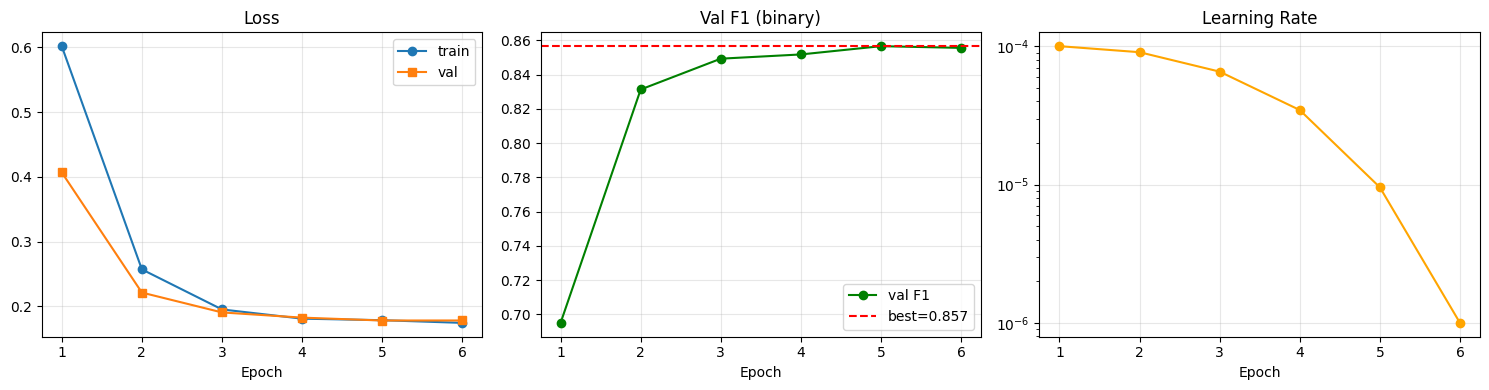

Saved: training_curves.png


In [19]:
# ── Кривые обучения ───────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], marker='o', label='train')
axes[0].plot(epochs_range, history['val_loss'],   marker='s', label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_f1'], marker='o', color='green', label='val F1')
axes[1].axhline(y=best_val_f1, color='red', ls='--', label=f'best={best_val_f1:.3f}')
axes[1].set_title('Val F1 (binary)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['lr'], marker='o', color='orange')
axes[2].set_title('Learning Rate'); axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

## 13. Экспорт

In [20]:
size_mb = os.path.getsize(MODEL_OUT) / 1e6
print(f'Веса сохранены: {MODEL_OUT}  ({size_mb:.1f} МБ)')

meta = {
    'clip_model_id':    CLIP_MODEL_ID,
    'embed_dim':        model.embed_dim,
    'head_architecture': 'LayerNorm → Dropout(0.2) → Linear(512,128) → GELU → Dropout(0.1) → Linear(128,2)',
    'clip_mean':        list(CLIP_MEAN),
    'clip_std':         list(CLIP_STD),
    'clip_image_size':  CLIP_IMAGE_SIZE,
    'best_epoch':       best_epoch,
    'best_val_f1':      round(best_val_f1, 4),
    'val_roc_auc':      round(auc, 4) if not np.isnan(auc) else None,
    'train_size':       len(train_idx),
    'val_size':         len(val_idx),
    'hard_neg_multiplier': HARD_NEG_MULTIPLIER,
}

with open('clip_event_classifier_meta.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('\nМетаданные:')
for k, v in meta.items():
    print(f'  {k}: {v}')

print('\n───────────────────────────────────────────────')
print('Скачай clip_event_classifier.pt → bot/models/')
print('───────────────────────────────────────────────')

Веса сохранены: clip_event_classifier.pt  (0.3 МБ)

Метаданные:
  clip_model_id: openai/clip-vit-base-patch16
  embed_dim: 512
  head_architecture: LayerNorm → Dropout(0.2) → Linear(512,128) → GELU → Dropout(0.1) → Linear(128,2)
  clip_mean: [0.48145466, 0.4578275, 0.40821073]
  clip_std: [0.26862954, 0.26130258, 0.27577711]
  clip_image_size: 224
  best_epoch: 5
  best_val_f1: 0.8566
  val_roc_auc: 0.9857
  train_size: 14669
  val_size: 2589
  hard_neg_multiplier: 2.0

───────────────────────────────────────────────
Скачай clip_event_classifier.pt → bot/models/
───────────────────────────────────────────────


## 14. Опционально: загрузка на HuggingFace Hub

In [ ]:
UPLOAD_TO_HF = False          # Поставь True
HF_USERNAME  = 'your-username'  # ← замени
HF_REPO_NAME = 'clip-event-classifier-volunteer-plus'

if UPLOAD_TO_HF:
    from huggingface_hub import HfApi
    api = HfApi()
    repo_id = f'{HF_USERNAME}/{HF_REPO_NAME}'
    api.create_repo(repo_id, exist_ok=True, private=True)
    api.upload_file(MODEL_OUT, 'clip_event_classifier.pt', repo_id=repo_id)
    api.upload_file('clip_event_classifier_meta.json', 'meta.json', repo_id=repo_id)
    print(f'Загружено: https://hf.co/{repo_id}')
else:
    print(f'Скачай вручную: {MODEL_OUT}')